# Prática — Módulo 9 – K-Means

In [81]:
# Carregar o CSV no DataFrame
import pandas as pd

df = pd.read_csv("/content/dataset_textos_wikipedia.csv")

# **Pré-Processamento**

In [82]:
# Visualizar primeiras linhas
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        180 non-null    object
 1   tema_busca  180 non-null    object
 2   categoria   180 non-null    object
dtypes: object(3)
memory usage: 4.3+ KB
None


,text,tema_busca,categoria
0,desporto (português europeu) ou esporte (portu...,Desporto,esporte
1,cruzeiro esporte clube é uma associação polies...,Cruzeiro Esporte Clube,esporte
2,o esporte clube bahia é um clube esportivo bra...,Esporte Clube Bahia,esporte
3,"o esporte clube sírio é um clube esportivo, re...",Esporte Clube Sírio,esporte
4,"o blumenau esporte clube, popularmente conheci...",Blumenau Esporte Clube (1919),esporte
...,...,...,...
175,a culinária do oriente médio é uma mistura de ...,Culinária do Oriente Médio,culinaria
176,a mandioquinha ou batata-baroa (arracacia xant...,Arracacia xanthorrhiza,culinaria
177,culinária da polônia (polonês: kuchnia polska)...,Culinária da Polônia,culinaria
178,pato no tucupi é um prato brasileiro típico da...,Pato no tucupi,culinaria


## Pergunta
1. Quais categorias de assuntos existem no dataset?

In [83]:
df["categoria"].unique()

array(['esporte', 'tecnologia', 'politica', 'saude_beleza', 'religiao',
       'prehistoria', 'culinaria'], dtype=object)

## Pergunta

2. Os textos parecem homogêneos ou muito variados em tamanho?
3. Existe muito dado nulo ou inconsistente?


In [84]:
# Checar nulos
print("\nNulos por coluna:")
print(df.isnull().sum())

# Tamanho médio dos textos
df["text_len"] = df["text"].astype(str).apply(len)
print("\nTamanho médio dos textos:", df["text_len"].mean())


Nulos por coluna:
text          0
tema_busca    0
categoria     0
dtype: int64

Tamanho médio dos textos: 514.2222222222222


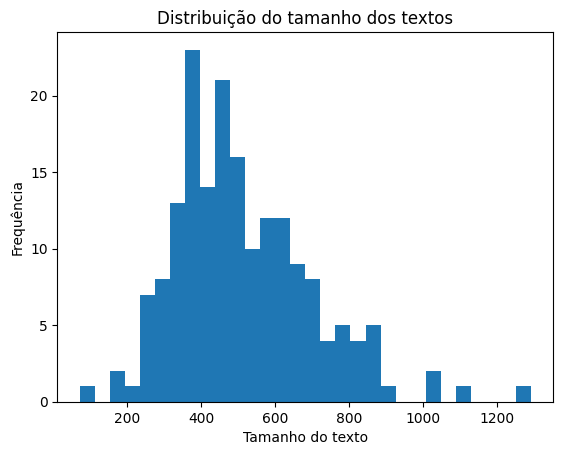

In [85]:
# Visualizar histograma do tamanho dos textos
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["text_len"], bins=30)
plt.xlabel("Tamanho do texto")
plt.ylabel("Frequência")
plt.title("Distribuição do tamanho dos textos")
plt.show()

## Pergunta

4. O texto, do jeito que está, pode ser usado pelo K-means?  

In [86]:
# Limpar os textos para reduzir ruído antes da vetorização
import re

def limpar_texto(t):
    t = str(t).lower()
    t = re.sub(r'\d+', ' ', t)            # remove números
    t = re.sub(r'[^\w\s]', ' ', t)        # remove pontuação
    t = re.sub(r'\s+', ' ', t).strip()    # normaliza espaços
    return t

df["text_clean"] = df["text"].apply(limpar_texto)

print(df[["text", "text_clean"]].head())

                                                text  \
0  desporto (português europeu) ou esporte (portu...   
1  cruzeiro esporte clube é uma associação polies...   
2  o esporte clube bahia é um clube esportivo bra...   
3  o esporte clube sírio é um clube esportivo, re...   
4  o blumenau esporte clube, popularmente conheci...   

                                          text_clean  
0  desporto português europeu ou esporte portuguê...  
1  cruzeiro esporte clube é uma associação polies...  
2  o esporte clube bahia é um clube esportivo bra...  
3  o esporte clube sírio é um clube esportivo rec...  
4  o blumenau esporte clube popularmente conhecid...  


## Pergunta
5. Ao utilizar TF-IDF, a remoção de stopwords é obrigatória? Explique o impacto dessa decisão no modelo.

In [87]:
# Remover stopwords (português)
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

stopwords_pt = set(stopwords.words('portuguese'))

def remover_stopwords(t):
    return " ".join([w for w in t.split() if w not in stopwords_pt])

df["text_clean"] = df["text_clean"].apply(remover_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [88]:
# Gerar matriz TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=4000
)

X = vectorizer.fit_transform(df["text_clean"])

print("Shape da matriz:", X.shape)

Shape da matriz: (180, 3770)


# **K-Means**

## Pergunta
6. Escolher um número arbitrário de clusters pode comprometer o resultado?   
7. Como saber quantos grupos (clusters) escolher?

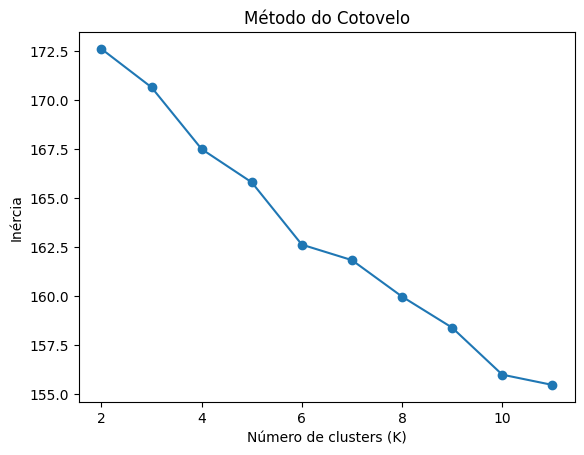

In [89]:
# Avaliar diferentes valores de K (método do cotovelo)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

## Pergunta
8. Se a inércia diminui linearmente (não há "cotovelo"), qual critério usar para escolher K?

In [90]:
# Treinar modelo final com K escolhido
k = 9

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df[["text", "cluster"]]

,text,cluster
0,desporto (português europeu) ou esporte (portu...,4
1,cruzeiro esporte clube é uma associação polies...,4
2,o esporte clube bahia é um clube esportivo bra...,4
3,"o esporte clube sírio é um clube esportivo, re...",4
4,"o blumenau esporte clube, popularmente conheci...",4
...,...,...
175,a culinária do oriente médio é uma mistura de ...,2
176,a mandioquinha ou batata-baroa (arracacia xant...,2
177,culinária da polônia (polonês: kuchnia polska)...,2
178,pato no tucupi é um prato brasileiro típico da...,6


# Pergunta
9. Como entender o que cada cluster representa na prática? Ou seja, o algoritmo “nomeia” os grupos automaticamente ou isso depende de interpretação?

In [91]:
# Visualizar exemplos de textos por cluster
for i in range(k):
    print(f"\nCluster {i}")
    print(df[df["cluster"] == i]["text"].head(3).values)


Cluster 0
['o ministério do esporte (me) é um ministério brasileiro criado em 1995 pelo então presidente fernando henrique cardoso.\n\n\n== história ==\n\n\n=== ministério da educação e cultura ===\na história institucional do esporte no brasil teve início em 1937, quando, por intermédio da lei n° 378 de 13 de janeiro de 1937, foi criada a divisão de educação física do ministério da educação e cultura (def), que teve como diretores: major joão barbosa leite, coronel caio mário de noronha miranda, professor alfredo colombo, general antônio pires de castro filho, coronel genival de freitas e coronel arthur orlando da costa ferreira.\nem 1970, a divisão foi transformada em departamento de educação física e desportos, ainda veiculada ao ministério da educação e cultura, e teve como diretores: coronel eric tinoco marques e coronel osny vasconcellos.'
 'tecnologia (do grego "τέχνη": "técnica, arte, ofício" e "-λογία": "estudo") é o conjunto de processos e habilidades usados na produção de b

## Pergunta
10. Como visualizar dados de alta dimensão (TF-IDF) em 2D?    

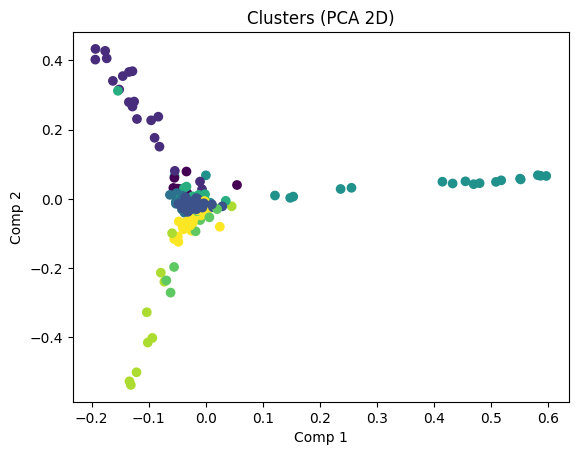

In [92]:
# Reduzir para 2D e plot
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_reduced_2d = PCA(n_components=2).fit_transform(X.toarray())

plt.scatter(
    X_reduced_2d[:,0],
    X_reduced_2d[:,1],
    c=df["cluster"]
)

plt.xlabel("Comp 1")
plt.ylabel("Comp 2")
plt.title("Clusters (PCA 2D)")
plt.show()

## Pergunta
11. A partir da visualização dos clusters, é possível identificar sobreposição entre grupos?
12. Projetar em 3 dimensões ajuda a enxergar melhor a separação dos clusters?   

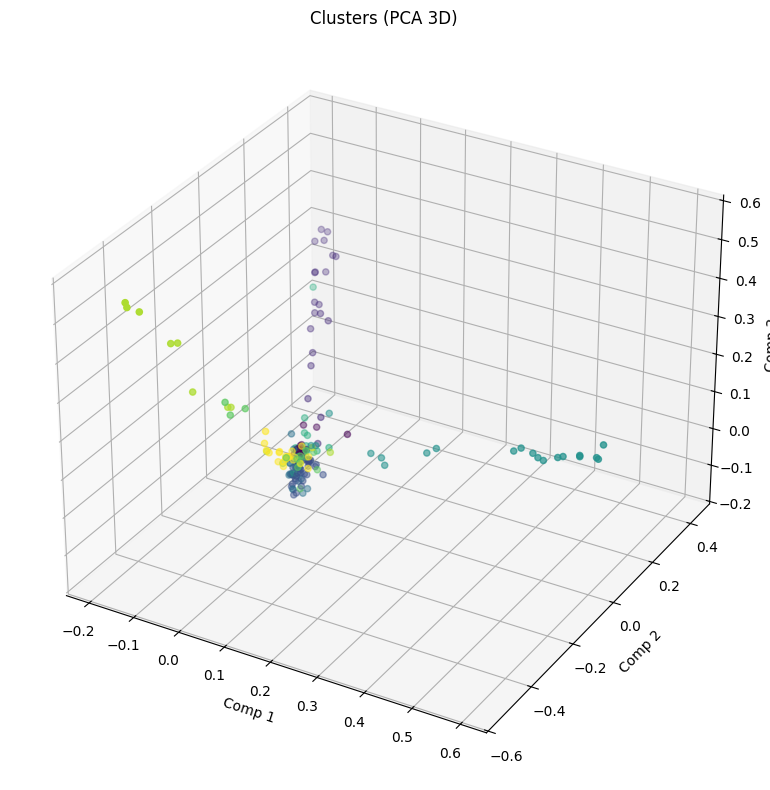

In [93]:
# Reduzir para 3D e plot
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_reduced_3d = PCA(n_components=3).fit_transform(X.toarray())

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_reduced_3d[:,0],
    X_reduced_3d[:,1],
    X_reduced_3d[:,2],
    c=df["cluster"]
)

ax.set_xlabel("Comp 1")
ax.set_ylabel("Comp 2")
ax.set_zlabel("Comp 3")

plt.title("Clusters (PCA 3D)")
plt.tight_layout()
plt.show()

# **Avaliação**

## **RI e ARI**

### Pergunta
13. Quais métricas numéricas podem ser utilizadas para avaliar o desempenho de algoritmos de clusterização?
14. Para aplicar métricas como o Índice Rand ou o Índice Rand Ajustado, é necessário possuir rótulos reais dos dados? Explique.

In [94]:
# Avaliação com Rand Index
from sklearn.metrics import adjusted_rand_score, rand_score

y_true = df["categoria"]  # ou nome da sua coluna real
y_pred = kmeans.labels_

ri = rand_score(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)

print("Rand Index:", ri)
print("Adjusted Rand Index:", ari)

Rand Index: 0.9215394165114835
Adjusted Rand Index: 0.6598771397733009


### Pergunta
15. Qual seria o melhor k Segundo RI e ARI?

In [95]:
# Avaliar RI e ARI para diferentes valores de K

from sklearn.cluster import KMeans
from sklearn.metrics import rand_score, adjusted_rand_score

valores_k = range(2, 15)

RI = []
ARI = []

y_true = df["categoria"]

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    RI.append(rand_score(y_true, labels))
    ARI.append(adjusted_rand_score(y_true, labels))

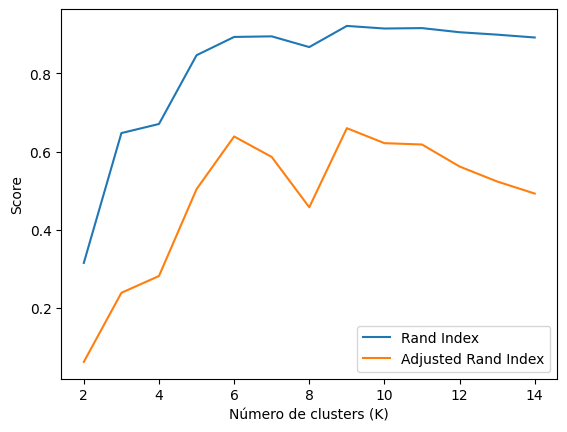

In [96]:
# Plotar resultados
import matplotlib.pyplot as plt

plt.figure()

plt.plot(valores_k, RI, label="Rand Index")
plt.plot(valores_k, ARI, label="Adjusted Rand Index")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Score")
plt.legend()

plt.show()

## **Silhueta**

### Pergunta
15. Em um cenário onde não há rótulos disponíveis, quais estratégias podem ser utilizadas para avaliar a qualidade dos clusters?

In [97]:
# Calcular coeficiente de silhueta
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)

print("Silhouette Score:", score)

Silhouette Score: 0.025564921625544666


### Pergunta
16. Se o coeficiente de silhueta é calculado para cada ponto do conjunto de dados, o que representa o Silhouette Score final apresentado pelo modelo?  
Resp.: O Silhouette Score corresponde à média dos coeficientes de silhueta calculados para todos os pontos do conjunto de dados. A análise individual é interessante porque permite identificar pontos mal alocados, regiões de sobreposição entre clusters e possíveis problemas na estrutura dos agrupamentos, que podem não ser percebidos apenas pelo valor médio.

In [98]:
# Silhueta por ponto
from sklearn.metrics import silhouette_samples

sil_values = silhouette_samples(X, kmeans.labels_)

df["silhouette"] = sil_values

df[["text", "categoria", "silhouette"]]

,text,categoria,silhouette
0,desporto (português europeu) ou esporte (portu...,esporte,-0.012759
1,cruzeiro esporte clube é uma associação polies...,esporte,0.033652
2,o esporte clube bahia é um clube esportivo bra...,esporte,0.094019
3,"o esporte clube sírio é um clube esportivo, re...",esporte,0.123495
4,"o blumenau esporte clube, popularmente conheci...",esporte,0.113391
...,...,...,...
175,a culinária do oriente médio é uma mistura de ...,culinaria,0.009957
176,a mandioquinha ou batata-baroa (arracacia xant...,culinaria,-0.014536
177,culinária da polônia (polonês: kuchnia polska)...,culinaria,-0.005390
178,pato no tucupi é um prato brasileiro típico da...,culinaria,0.028734


### Pergunta
17. Qual seria o melhor k segundo o Silhouette Score?

In [99]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

valores_k = range(2, 15)
silhouette_scores = []

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

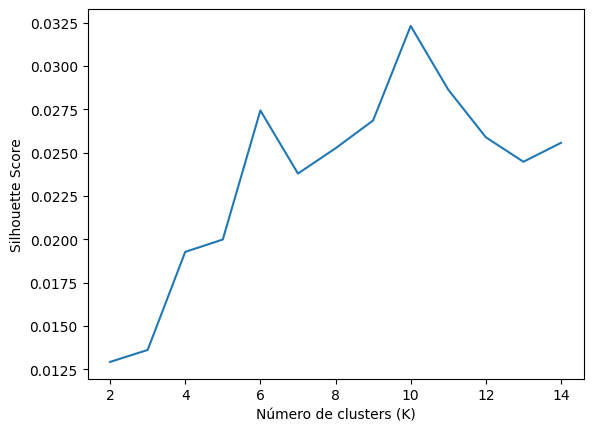

In [100]:
import matplotlib.pyplot as plt

plt.plot(valores_k, silhouette_scores)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")

plt.show()

### Pergunta
18. Considerando os gráficos de Silhouette Score e ARI, observa-se um melhor desempenho em torno de K=9. No entanto, sabemos que o problema possui 6 categorias reais e que o gráfico do método do cotovelo foi inconclusivo. Como explicar esse resultado?